<h2 align="center">Salary Distribution (Seaborn)</h2>

In [2]:
# importing the libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

# loading the dataset
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# sorting by date
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

# converting job_skills from string to list
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else [])

In [ ]:
# selecting the Data Analyst job in United States
DE_US_df = df[(df['job_title_short'] == 'Data Engineer') & (df['job_country'] == 'United States')].copy()

# now removing the NaN values from salary_year_avg
DE_US_df = DE_US_df.dropna(subset=['salary_year_avg'])

DE_US_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2915 entries, 92 to 785641
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   job_title_short        2915 non-null   object        
 1   job_title              2915 non-null   object        
 2   job_location           2869 non-null   object        
 3   job_via                2915 non-null   object        
 4   job_schedule_type      2915 non-null   object        
 5   job_work_from_home     2915 non-null   bool          
 6   search_location        2915 non-null   object        
 7   job_posted_date        2915 non-null   datetime64[ns]
 8   job_no_degree_mention  2915 non-null   bool          
 9   job_health_insurance   2915 non-null   bool          
 10  job_country            2915 non-null   object        
 11  salary_rate            2915 non-null   object        
 12  salary_year_avg        2915 non-null   float64       
 13  salar

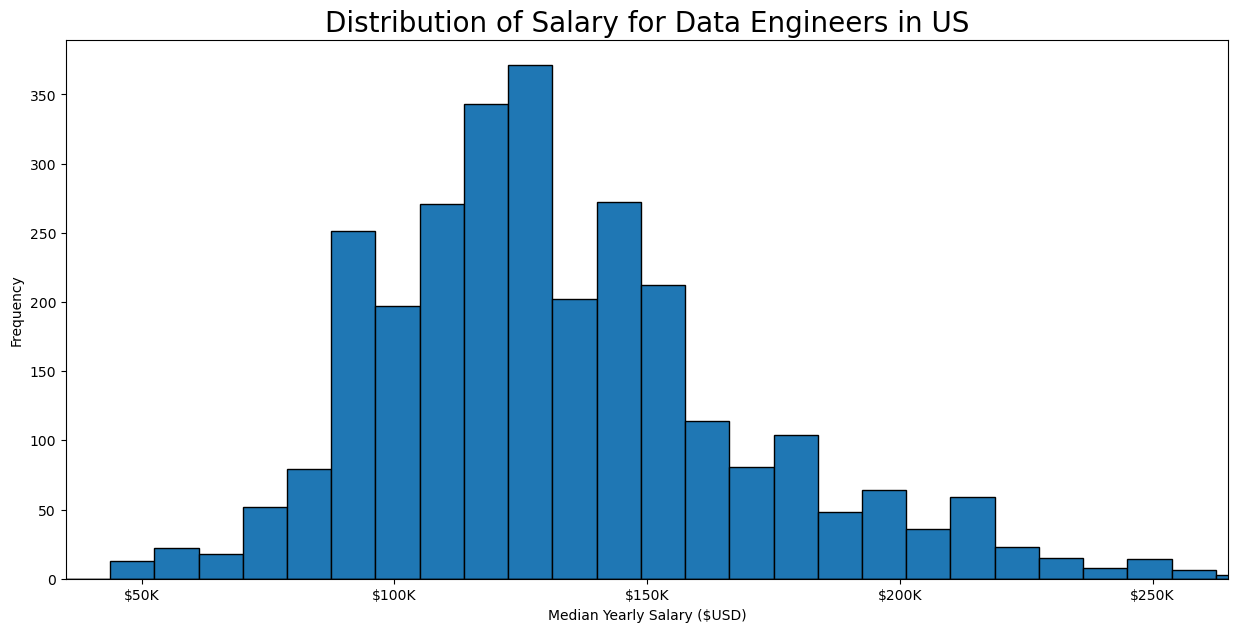

In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# histogram
DE_US_df.plot(kind='hist', bins=60, edgecolor='black', figsize=(15,7))

# formatting
plt.legend().set_visible(False)
plt.xlim(35000, 265000)

# axis formatters
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# naming
plt.xlabel('Median Yearly Salary ($USD)')
plt.ylabel('Frequency')
plt.title('Distribution of Salary for Data Engineers in US', fontsize=20)

plt.show()

# Histogram Using Seaborn Visualization

C:\Users\mrpra\AppData\Local\Temp\ipykernel_28204\1541317040.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().set_visible(False)


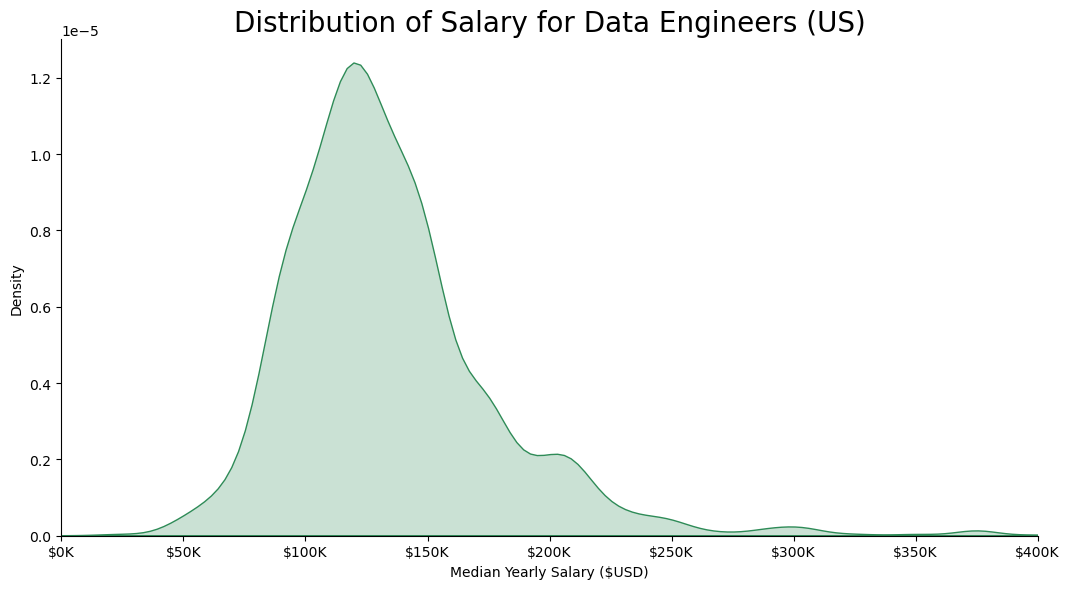

In [30]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# histogram
# DE_US_df.plot(kind='hist', bins=60, edgecolor='black', figsize=(15,7))

sns.displot(DE_US_df['salary_year_avg'], kind='kde',fill=True, color='seagreen',height=6, aspect=1.8)


# formatting
plt.legend().set_visible(False)
plt.xlim(0, 400000)

# axis formatters
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${int(x/1000)}K'))

# naming
plt.xlabel('Median Yearly Salary ($USD)')
plt.ylabel('Density') # Density is the probability of a random variable taking on a particular value
plt.title('Distribution of Salary for Data Engineers (US)', fontsize=20)
plt.tight_layout()

plt.show()